# Investigation 02 — Residual control false-positive error analysis

This notebook examines the main remaining error pattern after the v2 abstention mechanism: weak-schema control records that still receive a substantive image schema.

Thesis use:
- Supports the Results error-analysis section.
- Provides examples for the Discussion.
- Tests whether residual over-attribution is concentrated in particular providers, prompts, conditions, sentences, or predicted schemas.

In [1]:
from __future__ import annotations

import json
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Run from the project notebooks/ directory.
PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
OUTPUTS_DIR = DATA_DIR / "outputs"
PARSED_PATH = OUTPUTS_DIR / "parsed_responses.jsonl"
RAW_PATH = OUTPUTS_DIR / "raw_responses.jsonl"
GOLD_PATH = DATA_DIR / "gold" / "sentences_v1.jsonl"

EXPORT_DIR = OUTPUTS_DIR / "top4_investigations"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

def read_jsonl(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line_no, line in enumerate(f, start=1):
            if line.strip():
                try:
                    rows.append(json.loads(line))
                except json.JSONDecodeError as exc:
                    raise ValueError(f"Invalid JSON in {path} line {line_no}: {exc}") from exc
    return pd.DataFrame(rows)

def safe_read_jsonl(path: Path) -> pd.DataFrame:
    return read_jsonl(path) if path.exists() else pd.DataFrame()

def prompt_generation(prompt_id) -> str:
    prompt_id = str(prompt_id)
    if "v2" in prompt_id or "abstention" in prompt_id:
        return "v2_abstention"
    if "v1" in prompt_id:
        return "v1"
    return "unknown"

def prompt_base(prompt_id: str) -> str:
    prompt_id = str(prompt_id)
    if "direct_schema" in prompt_id:
        return "direct_schema"
    if "structured_roles" in prompt_id:
        return "structured_roles"
    if "naive" in prompt_id:
        return "naive"
    return "unknown"

def condition_family_from_id(condition_id) -> str:
    condition_id = str(condition_id)
    if "temp_0" in condition_id:
        return "temp_0"
    if "temp_03" in condition_id:
        return "temp_03"
    if "temp_07" in condition_id:
        return "temp_07"
    return condition_id

def add_derived_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["prompt_generation"] = out["prompt_id"].map(prompt_generation) if "prompt_id" in out.columns else "unknown"
    out["prompt_base"] = out["prompt_id"].map(prompt_base) if "prompt_id" in out.columns else "unknown"
    out["condition_family_short"] = out["condition_id"].map(condition_family_from_id) if "condition_id" in out.columns else "unknown"
    out["is_control"] = out["sentence_type"].eq("control_weak_schema") if "sentence_type" in out.columns else False
    out["is_non_control"] = ~out["is_control"]

    if "schema_present" not in out.columns:
        out["schema_present"] = np.where(out.get("main_image_schema", pd.Series()).eq("NONE"), "no", "yes")
    out["gold_schema_present"] = np.where(out["is_control"], "no", "yes")

    out["schema_present_correct"] = out["schema_present"].eq(out["gold_schema_present"])
    out["primary_schema_correct"] = out["main_image_schema"].eq(out["expected_schema_primary"])
    out["lm_correct"] = out["literal_or_metaphorical"].eq(out["expected_literal_or_metaphorical"])
    out["control_correct"] = out["is_control"] & out["literal_or_metaphorical"].eq("control") & out["main_image_schema"].eq("NONE")
    out["control_false_positive_schema"] = out["is_control"] & out["main_image_schema"].notna() & ~out["main_image_schema"].eq("NONE")
    out["predicted_none"] = out["main_image_schema"].eq("NONE") | out["literal_or_metaphorical"].eq("control") | out["schema_present"].eq("no")
    return out

def pct(x, digits=1):
    if x is None or pd.isna(x):
        return "NA"
    return f"{100*x:.{digits}f}%"

def save_csv(df: pd.DataFrame, filename: str) -> Path:
    path = EXPORT_DIR / filename
    df.to_csv(path, index=False)
    print(f"Wrote: {path}")
    return path

def display_percent_table(df: pd.DataFrame, percent_cols: list[str]) -> pd.DataFrame:
    out = df.copy()
    for col in percent_cols:
        if col in out.columns:
            out[col] = out[col].map(lambda x: pct(x) if x is not None else "NA")
    return out

parsed_all = add_derived_columns(read_jsonl(PARSED_PATH))
structured = parsed_all[parsed_all["parse_status"].eq("parsed")].copy()

print(f"All parsed records: {len(parsed_all)}")
print(f"Structured records: {len(structured)}")

All parsed records: 9000
Structured records: 7200


In [2]:
controls = structured[structured["is_control"]].copy()
controls["false_positive"] = controls["control_false_positive_schema"]
controls["correct_none"] = controls["control_correct"]

print(f"Control records: {len(controls)}")
print(f"Control false-positive rate: {controls['false_positive'].mean():.3f}")
display(controls.head())

Control records: 2376
Control false-positive rate: 0.322


,run_key,run_index,provider,model_id,model_name,prompt_id,prompt_family,prompt_version,condition_id,condition_family,...,is_non_control,gold_schema_present,schema_present_correct,primary_schema_correct,lm_correct,control_correct,control_false_positive_schema,predicted_none,false_positive,correct_none
643,openai_gpt_5_4_mini|p_direct_schema_v1|c_temp_...,623,openai,openai_gpt_5_4_mini,gpt-5.4-mini,p_direct_schema_v1,direct_schema,v1.0,c_temp_0_v1,deterministic,...,False,no,True,True,True,True,False,True,False,True
644,openai_gpt_5_4_mini|p_direct_schema_v1|c_temp_...,624,openai,openai_gpt_5_4_mini,gpt-5.4-mini,p_direct_schema_v1,direct_schema,v1.0,c_temp_0_v1,deterministic,...,False,no,True,True,True,True,False,True,False,True
645,openai_gpt_5_4_mini|p_direct_schema_v1|c_temp_...,625,openai,openai_gpt_5_4_mini,gpt-5.4-mini,p_direct_schema_v1,direct_schema,v1.0,c_temp_0_v1,deterministic,...,False,no,True,True,True,True,False,True,False,True
646,openai_gpt_5_4_mini|p_direct_schema_v1|c_temp_...,626,openai,openai_gpt_5_4_mini,gpt-5.4-mini,p_direct_schema_v1,direct_schema,v1.0,c_temp_0_v1,deterministic,...,False,no,True,True,True,True,False,True,False,True
647,openai_gpt_5_4_mini|p_direct_schema_v1|c_temp_...,627,openai,openai_gpt_5_4_mini,gpt-5.4-mini,p_direct_schema_v1,direct_schema,v1.0,c_temp_0_v1,deterministic,...,False,no,True,True,True,True,False,True,False,True


In [3]:
# Residual false-positive counts and rates by prompt/provider/model.
def fp_summary(group_cols):
    rows = []
    for keys, g in controls.groupby(group_cols, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)
        row = dict(zip(group_cols, keys))
        row["n"] = len(g)
        row["false_positive_n"] = int(g["false_positive"].sum())
        row["false_positive_rate"] = g["false_positive"].mean()
        row["correct_none_rate"] = g["correct_none"].mean()
        rows.append(row)
    return pd.DataFrame(rows)

fp_by_prompt = fp_summary(["prompt_id", "prompt_generation", "prompt_base"])
fp_by_provider_prompt = fp_summary(["provider", "model_id", "prompt_id"])
fp_by_condition = fp_summary(["prompt_id", "condition_id", "condition_family_short"])

save_csv(fp_by_prompt, "control_false_positive_by_prompt.csv")
save_csv(fp_by_provider_prompt, "control_false_positive_by_provider_prompt.csv")
save_csv(fp_by_condition, "control_false_positive_by_condition.csv")

display(display_percent_table(fp_by_prompt, ["false_positive_rate", "correct_none_rate"]))
display(display_percent_table(fp_by_provider_prompt, ["false_positive_rate", "correct_none_rate"]))

Wrote: /Users/Shared/image_schema_llm_project/data/outputs/top4_investigations/control_false_positive_by_prompt.csv
Wrote: /Users/Shared/image_schema_llm_project/data/outputs/top4_investigations/control_false_positive_by_provider_prompt.csv
Wrote: /Users/Shared/image_schema_llm_project/data/outputs/top4_investigations/control_false_positive_by_condition.csv


,prompt_id,prompt_generation,prompt_base,n,false_positive_n,false_positive_rate,correct_none_rate
0,p_direct_schema_v1,v1,direct_schema,594,345,58.1%,41.9%
1,p_direct_schema_v2_abstention,v2_abstention,direct_schema,594,128,21.5%,78.5%
2,p_structured_roles_v1,v1,structured_roles,594,162,27.3%,72.7%
3,p_structured_roles_v2_abstention,v2_abstention,structured_roles,594,129,21.7%,78.3%


,provider,model_id,prompt_id,n,false_positive_n,false_positive_rate,correct_none_rate
0,anthropic,claude_sonnet_4_6,p_direct_schema_v1,198,189,95.5%,4.5%
1,anthropic,claude_sonnet_4_6,p_direct_schema_v2_abstention,198,47,23.7%,76.3%
2,anthropic,claude_sonnet_4_6,p_structured_roles_v1,198,53,26.8%,73.2%
3,anthropic,claude_sonnet_4_6,p_structured_roles_v2_abstention,198,55,27.8%,72.2%
4,google,gemini_2_5_flash,p_direct_schema_v1,198,139,70.2%,29.8%
5,google,gemini_2_5_flash,p_direct_schema_v2_abstention,198,77,38.9%,61.1%
6,google,gemini_2_5_flash,p_structured_roles_v1,198,104,52.5%,47.5%
7,google,gemini_2_5_flash,p_structured_roles_v2_abstention,198,69,34.8%,65.2%
8,openai,openai_gpt_5_4_mini,p_direct_schema_v1,198,17,8.6%,91.4%
9,openai,openai_gpt_5_4_mini,p_direct_schema_v2_abstention,198,4,2.0%,98.0%


In [4]:
# Which schemas are falsely assigned to controls?
fp_controls = controls[controls["false_positive"]].copy()

fp_schema = (
    fp_controls.groupby(["prompt_id", "main_image_schema"])
    .size()
    .reset_index(name="count")
    .sort_values(["prompt_id", "count"], ascending=[True, False])
)

fp_schema_provider = (
    fp_controls.groupby(["provider", "prompt_id", "main_image_schema"])
    .size()
    .reset_index(name="count")
    .sort_values(["provider", "prompt_id", "count"], ascending=[True, True, False])
)

save_csv(fp_schema, "control_false_positive_predicted_schema_counts.csv")
save_csv(fp_schema_provider, "control_false_positive_predicted_schema_by_provider.csv")

display(fp_schema)
display(fp_schema_provider.head(50))

Wrote: /Users/Shared/image_schema_llm_project/data/outputs/top4_investigations/control_false_positive_predicted_schema_counts.csv
Wrote: /Users/Shared/image_schema_llm_project/data/outputs/top4_investigations/control_false_positive_predicted_schema_by_provider.csv


,prompt_id,main_image_schema,count
1,p_direct_schema_v1,CONTAINER,157
3,p_direct_schema_v1,SOURCE_PATH_GOAL,134
2,p_direct_schema_v1,FORCE,38
5,p_direct_schema_v1,VERTICALITY,8
0,p_direct_schema_v1,BLOCKAGE,6
4,p_direct_schema_v1,SUPPORT_BALANCE,2
7,p_direct_schema_v2_abstention,CONTAINER,68
8,p_direct_schema_v2_abstention,FORCE,26
9,p_direct_schema_v2_abstention,SOURCE_PATH_GOAL,20
10,p_direct_schema_v2_abstention,VERTICALITY,8


,provider,prompt_id,main_image_schema,count
3,anthropic,p_direct_schema_v1,SOURCE_PATH_GOAL,86
1,anthropic,p_direct_schema_v1,CONTAINER,70
2,anthropic,p_direct_schema_v1,FORCE,27
0,anthropic,p_direct_schema_v1,BLOCKAGE,3
4,anthropic,p_direct_schema_v1,VERTICALITY,3
6,anthropic,p_direct_schema_v2_abstention,CONTAINER,26
7,anthropic,p_direct_schema_v2_abstention,FORCE,8
8,anthropic,p_direct_schema_v2_abstention,SOURCE_PATH_GOAL,7
5,anthropic,p_direct_schema_v2_abstention,BLOCKAGE,3
9,anthropic,p_direct_schema_v2_abstention,VERTICALITY,3


In [5]:
# Are some control sentences repeatedly misclassified?
sentence_fp = (
    controls.groupby(["sentence_id"])
    .agg(
        n=("run_key", "count"),
        false_positive_n=("false_positive", "sum"),
        false_positive_rate=("false_positive", "mean"),
        predicted_schemas=("main_image_schema", lambda s: "; ".join(sorted(set(map(str, s.dropna()))))),
        providers=("provider", lambda s: "; ".join(sorted(set(map(str, s.dropna()))))),
        prompts=("prompt_id", lambda s: "; ".join(sorted(set(map(str, s.dropna()))))),
    )
    .reset_index()
    .sort_values(["false_positive_rate", "false_positive_n"], ascending=[False, False])
)

# If gold file has sentence text, join it.
gold = safe_read_jsonl(GOLD_PATH)
if not gold.empty:
    text_col = "text" if "text" in gold.columns else "sentence" if "sentence" in gold.columns else None
    if text_col:
        sentence_fp = sentence_fp.merge(
            gold[["sentence_id", text_col]].rename(columns={text_col: "sentence_text"}),
            on="sentence_id",
            how="left",
        )

save_csv(sentence_fp, "control_sentence_false_positive_rates.csv")
display(sentence_fp.head(30))

Wrote: /Users/Shared/image_schema_llm_project/data/outputs/top4_investigations/control_sentence_false_positive_rates.csv


,sentence_id,n,false_positive_n,false_positive_rate,predicted_schemas,providers,prompts,sentence_text
0,s0098,36,36,1.000000,CONTAINER; SOURCE_PATH_GOAL,anthropic; google; openai,p_direct_schema_v1; p_direct_schema_v2_abstent...,The driver parked near the school.
1,s0167,36,30,0.833333,CONTAINER; FORCE; NONE,anthropic; google; openai,p_direct_schema_v1; p_direct_schema_v2_abstent...,The student opened the notebook.
2,s0129,36,27,0.750000,CONTAINER; NONE,anthropic; google; openai,p_direct_schema_v1; p_direct_schema_v2_abstent...,The parent packed the lunch.
3,s0161,36,27,0.750000,FORCE; NONE,anthropic; google; openai,p_direct_schema_v1; p_direct_schema_v2_abstent...,The gardener trimmed the hedge.
4,s0197,36,26,0.722222,CONTAINER; NONE; SOURCE_PATH_GOAL,anthropic; google; openai,p_direct_schema_v1; p_direct_schema_v2_abstent...,The child drew a circle.
5,s0027,36,24,0.666667,CONTAINER; FORCE; NONE; SOURCE_PATH_GOAL,anthropic; google; openai,p_direct_schema_v1; p_direct_schema_v2_abstent...,The gardener watered the roses at dawn.
6,s0158,36,24,0.666667,BLOCKAGE; NONE,anthropic; google; openai,p_direct_schema_v1; p_direct_schema_v2_abstent...,The committee delayed the decision.
7,s0025,36,23,0.638889,CONTAINER; NONE; SOURCE_PATH_GOAL,anthropic; google; openai,p_direct_schema_v1; p_direct_schema_v2_abstent...,The musician practised for an hour.
8,s0125,36,23,0.638889,NONE; SOURCE_PATH_GOAL; VERTICALITY,anthropic; google; openai,p_direct_schema_v1; p_direct_schema_v2_abstent...,The singer warmed up quietly.
9,s0130,36,23,0.638889,CONTAINER; NONE; SOURCE_PATH_GOAL,anthropic; google; openai,p_direct_schema_v1; p_direct_schema_v2_abstent...,The intern filed the documents.


In [6]:
# Focus specifically on v2 residual false positives.
v2_fp = fp_controls[fp_controls["prompt_generation"].eq("v2_abstention")].copy()
v2_sentence_fp = (
    v2_fp.groupby(["sentence_id"])
    .agg(
        n=("run_key", "count"),
        providers=("provider", lambda s: "; ".join(sorted(set(map(str, s.dropna()))))),
        prompts=("prompt_id", lambda s: "; ".join(sorted(set(map(str, s.dropna()))))),
        predicted_schemas=("main_image_schema", lambda s: "; ".join(sorted(set(map(str, s.dropna()))))),
        predicted_lm=("literal_or_metaphorical", lambda s: "; ".join(sorted(set(map(str, s.dropna()))))),
    )
    .reset_index()
    .sort_values("n", ascending=False)
)

if not gold.empty and "sentence_text" not in v2_sentence_fp.columns:
    text_col = "text" if "text" in gold.columns else "sentence" if "sentence" in gold.columns else None
    if text_col:
        v2_sentence_fp = v2_sentence_fp.merge(
            gold[["sentence_id", text_col]].rename(columns={text_col: "sentence_text"}),
            on="sentence_id",
            how="left",
        )

save_csv(v2_sentence_fp, "v2_residual_control_false_positive_sentences.csv")
display(v2_sentence_fp.head(30))

Wrote: /Users/Shared/image_schema_llm_project/data/outputs/top4_investigations/v2_residual_control_false_positive_sentences.csv


,sentence_id,n,providers,prompts,predicted_schemas,predicted_lm,sentence_text
0,s0098,18,anthropic; google; openai,p_direct_schema_v2_abstention; p_structured_ro...,CONTAINER; SOURCE_PATH_GOAL,literal,The driver parked near the school.
1,s0167,13,anthropic; google; openai,p_direct_schema_v2_abstention; p_structured_ro...,CONTAINER; FORCE,literal,The student opened the notebook.
2,s0025,12,anthropic; google,p_direct_schema_v2_abstention; p_structured_ro...,CONTAINER; SOURCE_PATH_GOAL,metaphorical; uncertain,The musician practised for an hour.
3,s0197,12,anthropic; google,p_direct_schema_v2_abstention; p_structured_ro...,CONTAINER; SOURCE_PATH_GOAL,literal,The child drew a circle.
4,s0032,12,anthropic; google,p_direct_schema_v2_abstention; p_structured_ro...,FORCE; SOURCE_PATH_GOAL,literal,The photographer adjusted the lens.
5,s0165,12,anthropic; google,p_direct_schema_v2_abstention; p_structured_ro...,CONTAINER,literal; uncertain,The chef tasted the sauce.
6,s0161,12,anthropic; google,p_direct_schema_v2_abstention; p_structured_ro...,FORCE,literal,The gardener trimmed the hedge.
7,s0158,12,anthropic; google,p_direct_schema_v2_abstention; p_structured_ro...,BLOCKAGE,metaphorical,The committee delayed the decision.
8,s0134,12,anthropic; google,p_direct_schema_v2_abstention; p_structured_ro...,CONTAINER,metaphorical; uncertain,The student saved the file.
9,s0130,12,anthropic; google,p_direct_schema_v2_abstention; p_structured_ro...,CONTAINER,literal; uncertain,The intern filed the documents.


In [7]:
# Extract raw/parsed example records for qualitative analysis.
raw = safe_read_jsonl(RAW_PATH)
example_cols = [
    "run_key", "provider", "model_id", "prompt_id", "condition_id", "sentence_id",
    "main_image_schema", "literal_or_metaphorical", "schema_present", 
    "interpretation", "schema_explanation"
]

examples = v2_fp.sort_values(["sentence_id", "provider", "prompt_id"])[example_cols].copy()
if not raw.empty and "raw_response" in raw.columns:
    examples = examples.merge(raw[["run_key", "raw_response"]], on="run_key", how="left")

save_csv(examples, "v2_residual_control_false_positive_examples_with_raw.csv")
display(examples.head(20))

Wrote: /Users/Shared/image_schema_llm_project/data/outputs/top4_investigations/v2_residual_control_false_positive_examples_with_raw.csv


,run_key,provider,model_id,prompt_id,condition_id,sentence_id,main_image_schema,literal_or_metaphorical,schema_present,interpretation,schema_explanation,raw_response
0,claude_sonnet_4_6|p_direct_schema_v2_abstentio...,anthropic,claude_sonnet_4_6,p_direct_schema_v2_abstention,c_temp_0_v1,s0025,CONTAINER,uncertain,uncertain,The phrase 'for an hour' construes a unit of t...,The preposition 'for' combined with a time dur...,"```json\n{\n ""schema_present"": ""uncertain"",\n..."
1,claude_sonnet_4_6|p_direct_schema_v2_abstentio...,anthropic,claude_sonnet_4_6,p_direct_schema_v2_abstention,c_temp_03_v1,s0025,CONTAINER,uncertain,uncertain,The phrase 'for an hour' construes a unit of t...,The preposition 'for' combined with a time dur...,"```json\n{\n ""schema_present"": ""uncertain"",\n..."
2,claude_sonnet_4_6|p_direct_schema_v2_abstentio...,anthropic,claude_sonnet_4_6,p_direct_schema_v2_abstention,c_temp_03_v1,s0025,CONTAINER,uncertain,uncertain,The phrase 'for an hour' construes a unit of t...,The preposition 'for' combined with a time dur...,"```json\n{\n ""schema_present"": ""uncertain"",\n..."
3,claude_sonnet_4_6|p_structured_roles_v2_absten...,anthropic,claude_sonnet_4_6,p_structured_roles_v2_abstention,c_temp_0_v1,s0025,CONTAINER,metaphorical,yes,The phrase 'for an hour' construes time as a b...,English conventionally conceptualises duration...,"```json\n{\n ""schema_present"": ""yes"",\n ""lit..."
4,claude_sonnet_4_6|p_structured_roles_v2_absten...,anthropic,claude_sonnet_4_6,p_structured_roles_v2_abstention,c_temp_03_v1,s0025,CONTAINER,metaphorical,yes,The phrase 'for an hour' construes time as a b...,English conventionally maps time onto space: a...,"```json\n{\n ""schema_present"": ""yes"",\n ""lit..."
5,claude_sonnet_4_6|p_structured_roles_v2_absten...,anthropic,claude_sonnet_4_6,p_structured_roles_v2_abstention,c_temp_03_v1,s0025,CONTAINER,metaphorical,yes,The phrase 'for an hour' construes time as a b...,TIME AS CONTAINER: 'an hour' functions as a bo...,"```json\n{\n ""schema_present"": ""yes"",\n ""lit..."
6,gemini_2_5_flash|p_direct_schema_v2_abstention...,google,gemini_2_5_flash,p_direct_schema_v2_abstention,c_temp_0_v1,s0025,SOURCE_PATH_GOAL,metaphorical,yes,The musician performed the activity of practic...,The phrase 'for an hour' conceptualizes time a...,"{\n ""schema_present"": ""yes"",\n ""literal_or_m..."
7,gemini_2_5_flash|p_direct_schema_v2_abstention...,google,gemini_2_5_flash,p_direct_schema_v2_abstention,c_temp_03_v1,s0025,SOURCE_PATH_GOAL,metaphorical,yes,The musician engaged in the activity of practi...,"The phrase ""for an hour"" metaphorically maps t...","{\n ""schema_present"": ""yes"",\n ""literal_or_m..."
8,gemini_2_5_flash|p_direct_schema_v2_abstention...,google,gemini_2_5_flash,p_direct_schema_v2_abstention,c_temp_03_v1,s0025,SOURCE_PATH_GOAL,metaphorical,yes,The musician engaged in the activity of practi...,The phrase 'for an hour' metaphorically maps t...,"{\n ""schema_present"": ""yes"",\n ""literal_or_m..."
9,gemini_2_5_flash|p_structured_roles_v2_abstent...,google,gemini_2_5_flash,p_structured_roles_v2_abstention,c_temp_0_v1,s0025,SOURCE_PATH_GOAL,metaphorical,yes,The musician's act of practicing is conceptual...,The phrase 'for an hour' maps the abstract con...,"{\n ""schema_present"": ""yes"",\n ""literal_or_m..."


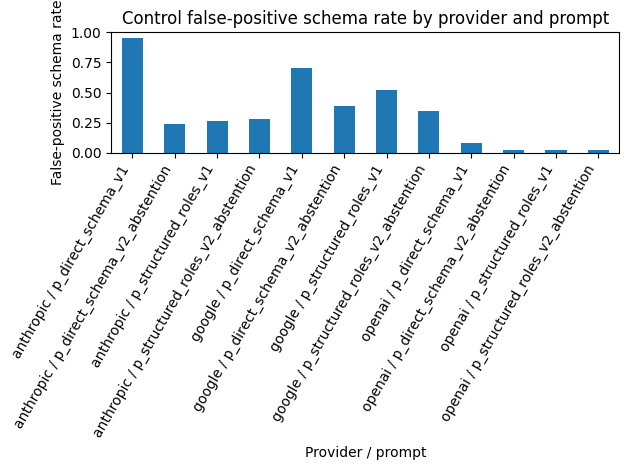

In [8]:
# Plot false-positive rate by provider and prompt.
plot_df = fp_by_provider_prompt.copy()
plot_df["label"] = plot_df["provider"] + " / " + plot_df["prompt_id"]
ax = plot_df.plot(kind="bar", x="label", y="false_positive_rate", legend=False)
ax.set_title("Control false-positive schema rate by provider and prompt")
ax.set_xlabel("Provider / prompt")
ax.set_ylabel("False-positive schema rate")
ax.set_ylim(0, 1)
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

## Thesis interpretation prompts

Look for:
- Control sentences repeatedly misclassified across models: possible annotation ambiguity or weak-control boundary problem.
- False positives concentrated in one provider: model conservatism difference.
- Repeated predicted labels such as `CONTAINER` or `SOURCE_PATH_GOAL`: suggests lexical cue over-attribution.
- v2 residual false positives: best source of qualitative Discussion examples.

Possible thesis claim:

> Residual v2 false positives show that abstention improves but does not solve the theoretical boundary problem. The system still sometimes turns abstract or administrative control sentences into schematic spatial interpretations.